In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df_dbscan = pd.read_csv("df_results_dbscan_only.csv")
df_results = pd.read_csv("df_results_without_dbscan.csv")

db_clean = df_dbscan.copy()
db_clean["Algorithm"] = "DBSCAN"

#fixing dataset naming to be consistent
db_clean["Dataset"] = db_clean["Dataset"].str.split("/").str[-1]

#align columns
common_cols = df_results.columns.intersection(db_clean.columns)
db_clean = db_clean[common_cols]
#merging the dfs 
df_all = pd.concat([df_results, db_clean], ignore_index=True)
df_all = df_all.drop("Unnamed: 0", axis='columns')
df_all.head(20)

,Dataset,Algorithm,ARI,NMI,NCA,Silhouette,Silhouette_W,Calinski_Harabasz,G_Dunn,Neg_Davies_Bouldin,Neg_WCSS,Battery,median_internal,median_reference
0,a1,K-means,0.890841,0.946220,0.907719,0.549520,0.547436,10905.204893,0.034414,-0.639906,-64.222075,sipu,0.290925,0.907719
1,a1,GMM,0.879836,0.942423,0.903158,0.545172,0.547277,10444.250648,0.040625,-0.644738,-67.014564,sipu,0.292898,0.903158
2,a1,Genie_g0.1,0.937118,0.958716,0.966667,0.585828,0.586648,13331.892006,0.379052,-0.540387,-52.668219,sipu,0.482440,0.958716
3,a1,Genie_g0.3,0.898836,0.952200,0.911579,0.563789,0.569258,11325.882022,0.258961,-0.575523,-61.869257,sipu,0.411375,0.911579
4,a1,Genie_g0.5,0.834178,0.937344,0.840000,0.481258,0.559391,8538.239593,0.301465,-0.611391,-81.704535,sipu,0.391362,0.840000
5,a1,Genie_g0.7,0.584754,0.865073,0.576491,0.146351,0.466938,3347.135167,0.251492,-0.889239,-202.748920,sipu,0.198921,0.584754
6,a1,Genie_g0.9,0.443571,0.787220,0.371228,0.013509,0.340636,1570.179112,0.293158,-inf,-411.360092,sipu,0.153333,0.443571
7,a1,Agg_single,0.443571,0.787220,0.371228,0.013509,0.340636,1570.179112,0.293158,-inf,-411.360092,sipu,0.153333,0.443571
8,a1,Agg_average,0.925094,0.951751,0.960000,0.581964,0.582859,13137.096064,0.339183,-0.541718,-53.439966,sipu,0.460573,0.951751
9,a1,Agg_complete,0.916228,0.950552,0.955439,0.575687,0.580996,12809.890146,0.181331,-0.556635,-54.788484,sipu,0.378509,0.950552


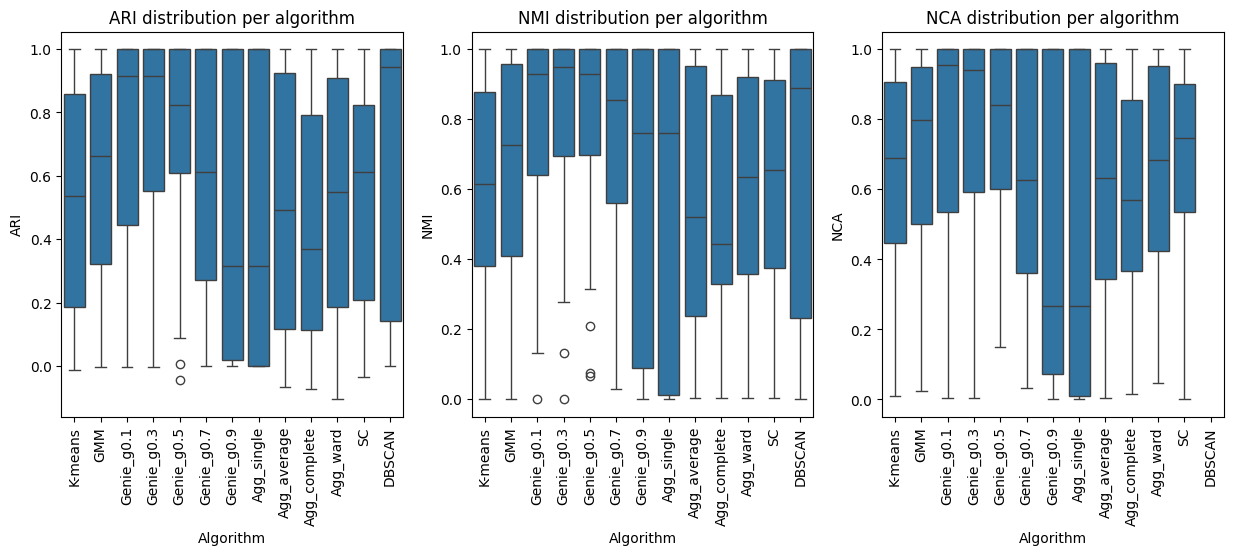

In [16]:
reference_metrics = ['ARI', 'NMI', 'NCA']
plt.figure(figsize=(15,5))
num=1
for metric in reference_metrics:
    plt.subplot(1,3, num)
    sns.boxplot(data=df_all, x="Algorithm", y=metric)
    plt.xticks(rotation=90)
    plt.title(f"{metric} distribution per algorithm")
    num+=1
plt.show()

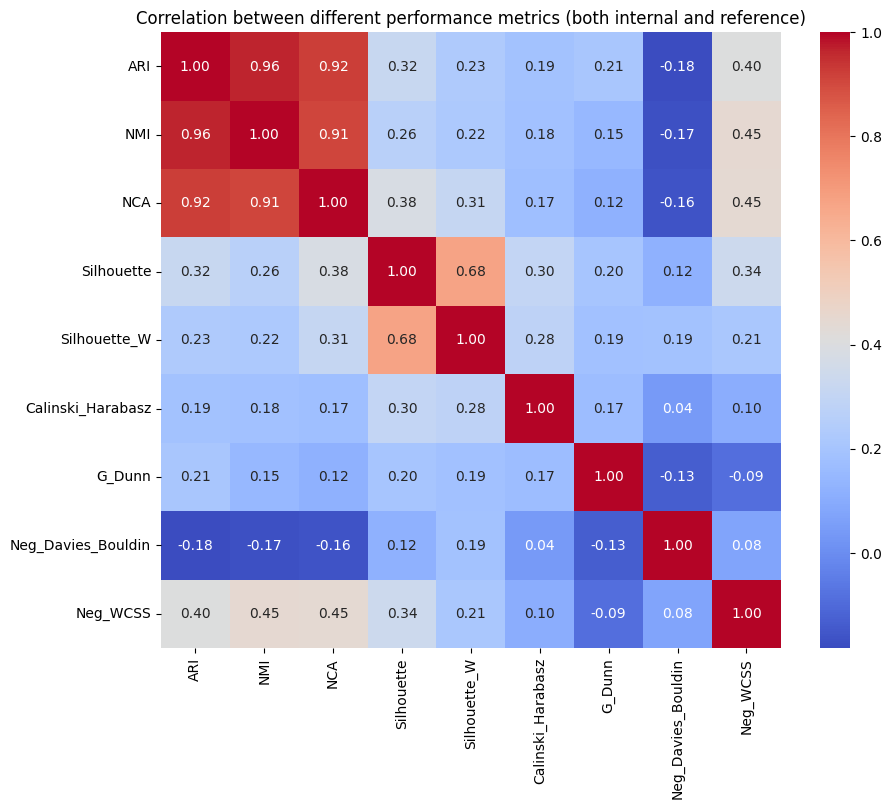

In [17]:
metrics = ['ARI', 'NMI', 'NCA', 'Silhouette', 'Silhouette_W', 'Calinski_Harabasz', 'G_Dunn', 'Neg_Davies_Bouldin', 'Neg_WCSS']
corr_matrix = df_all[metrics].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between different performance metrics (both internal and reference)')
plt.show()

C:\Users\basiu\AppData\Local\Temp\ipykernel_8184\3791730660.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  genie_data['g_val'] = genie_data['Algorithm'].str.extract('(\d+\.\d+)').astype(float)


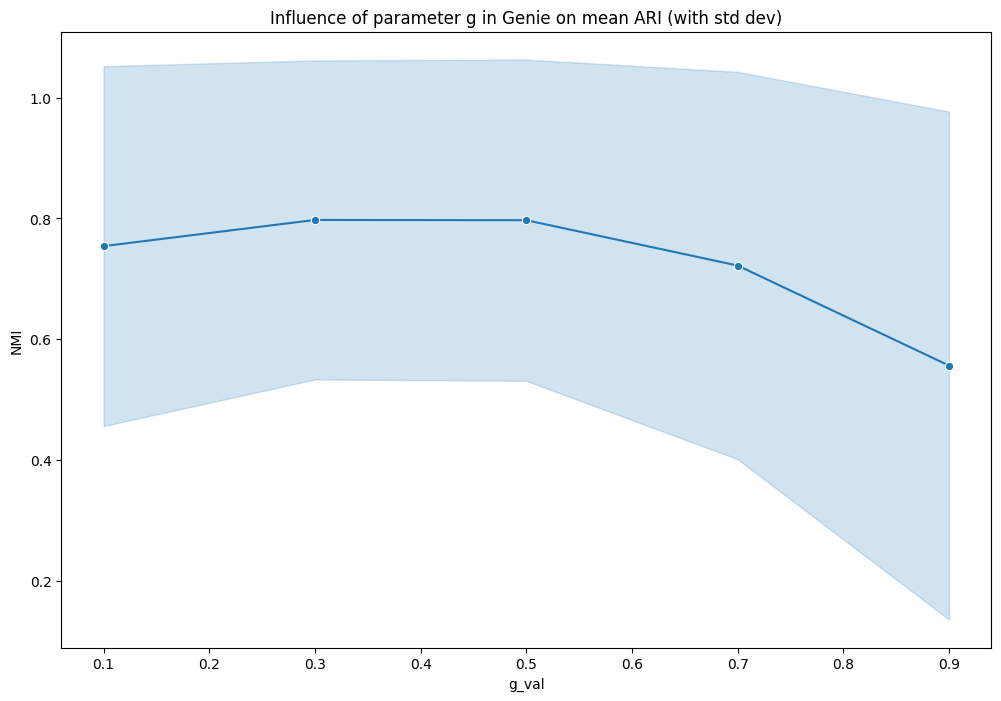

In [50]:
genie_data = df_results[df_results['Algorithm'].str.contains('Genie')]
genie_data['g_val'] = genie_data['Algorithm'].str.extract('(\d+\.\d+)').astype(float)
plt.figure(figsize=(12,8))
sns.lineplot(data=genie_data, x='g_val', y='NMI', marker='o',  errorbar="sd")
plt.title('Influence of parameter g in Genie on mean ARI (with std dev)')
plt.show()

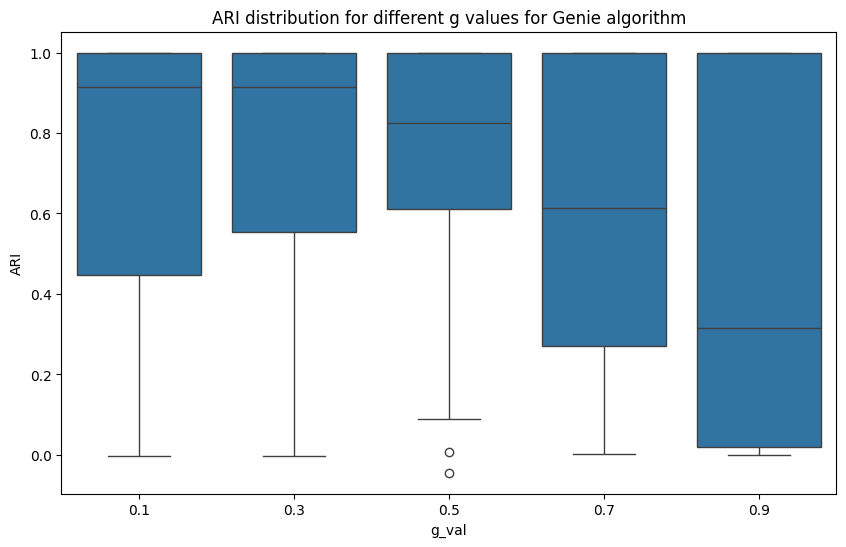

In [57]:
plt.figure(figsize=(10,6))
sns.boxplot(data=genie_data, x="g_val", y="ARI")
plt.title("ARI distribution for different g values for Genie algorithm")
plt.show()

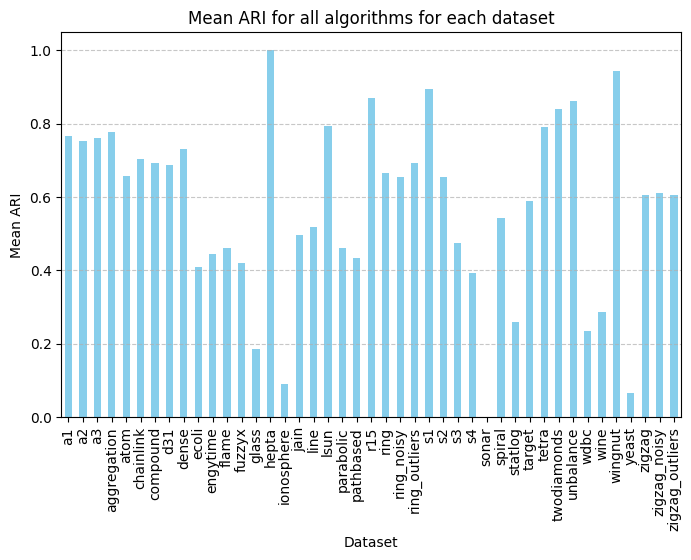

In [19]:
mean_ari = df_all.groupby('Dataset')['ARI'].mean()
mean_ari.plot(kind='bar', color='skyblue', figsize=(8, 5))
plt.title('Mean ARI for all algorithms for each dataset')
plt.xlabel('Dataset')
plt.ylabel('Mean ARI')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

C:\Users\basiu\AppData\Local\Temp\ipykernel_17272\3266353219.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  battery_positions = mean_ari.groupby('Battery').apply(
C:\Users\basiu\AppData\Local\Temp\ipykernel_17272\3266353219.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  battery_positions = mean_ari.groupby('Battery').apply(


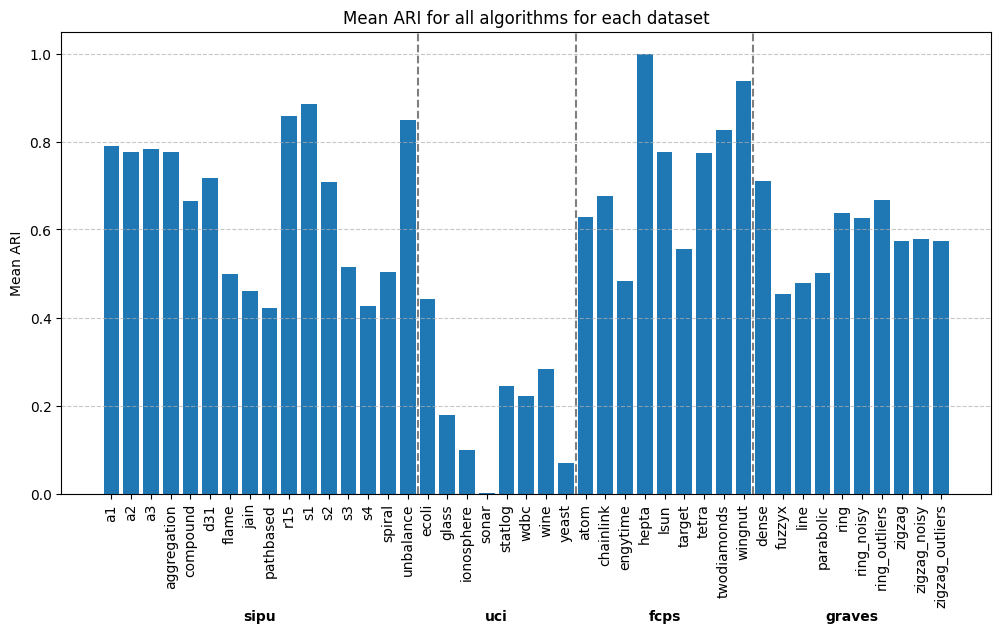

In [108]:
mean_ari = df_all.groupby(['Battery', 'Dataset'])['ARI'].mean().reset_index()
battery_order = ['sipu', 'uci', 'fcps', 'graves']
mean_ari['Battery'] = pd.Categorical(
    mean_ari['Battery'],
    categories=battery_order,
    ordered=True
)
mean_ari = mean_ari.sort_values(['Battery', 'Dataset'])
mean_ari = mean_ari.reset_index(drop=True)
plt.figure(figsize=(12, 6))
x = range(len(mean_ari))
plt.bar(x, mean_ari['ARI'])
plt.xticks(x, mean_ari['Dataset'], rotation=90)
plt.ylabel('Mean ARI')
plt.title('Mean ARI for all algorithms for each dataset')
plt.grid(axis='y', linestyle='--', alpha=0.7)

boundaries = []
current = mean_ari['Battery'].iloc[0]

for i, b in enumerate(mean_ari['Battery']):
    if b != current:
        boundaries.append(i)
        current = b

for b in boundaries:
    plt.axvline(b - 0.5, color='black', linestyle='--', alpha=0.5)
    
battery_positions = mean_ari.groupby('Battery').apply(
    lambda x: (x.index.min() + x.index.max()) / 2
)
for battery, pos in battery_positions.items():
    plt.text(pos, -0.25, battery,
             ha='center',
             va='top',
             transform=plt.gca().get_xaxis_transform(),
             fontsize=10,
             fontweight='bold')

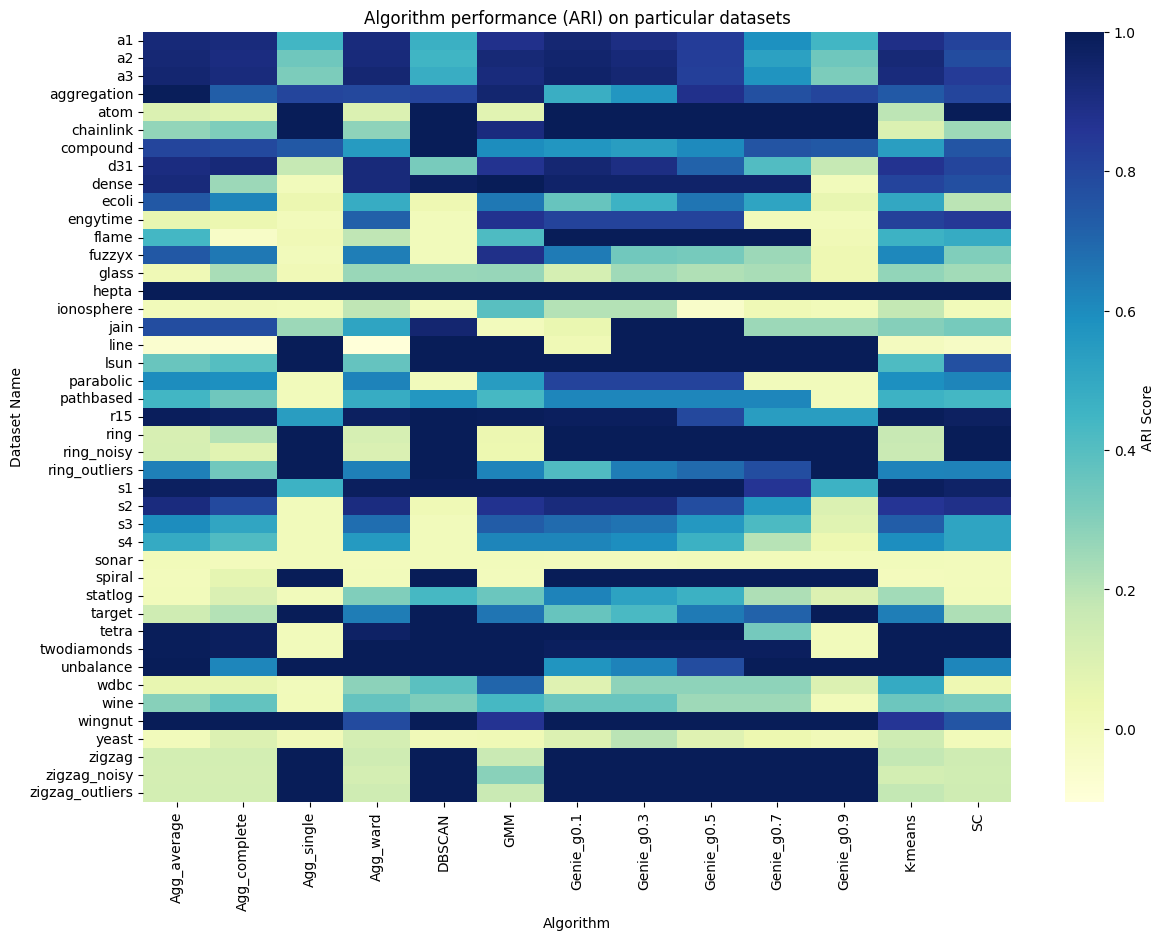

In [20]:
pivot_df = df_all.pivot(index='Dataset', columns='Algorithm', values='ARI')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, annot=False, cmap='YlGnBu', cbar_kws={'label': 'ARI Score'})
plt.title('Algorithm performance (ARI) on particular datasets')
plt.ylabel('Dataset Name')
plt.xlabel('Algorithm')
plt.show()

In [22]:
df_rank = df_all.copy()

df_rank["rank"] = df_rank.groupby("Dataset")["ARI"].rank(ascending=False)

avg_rank = df_rank.groupby("Algorithm")["rank"].mean().sort_values()
print(avg_rank)

Algorithm
Genie_g0.3      5.104651
Genie_g0.1      5.441860
Genie_g0.5      5.767442
GMM             5.813953
DBSCAN          6.406977
K-means         6.779070
Genie_g0.7      6.883721
Agg_ward        7.197674
Agg_average     7.360465
SC              8.232558
Agg_complete    8.395349
Genie_g0.9      8.546512
Agg_single      9.069767
Name: rank, dtype: float64


In [24]:
winners = df_all.loc[df_all.groupby("Dataset")["ARI"].idxmax()]
win_counts = winners["Algorithm"].value_counts()
print(win_counts)

Algorithm
Genie_g0.1     18
GMM            11
K-means         5
Agg_average     3
DBSCAN          2
Genie_g0.3      2
Genie_g0.9      2
Name: count, dtype: int64


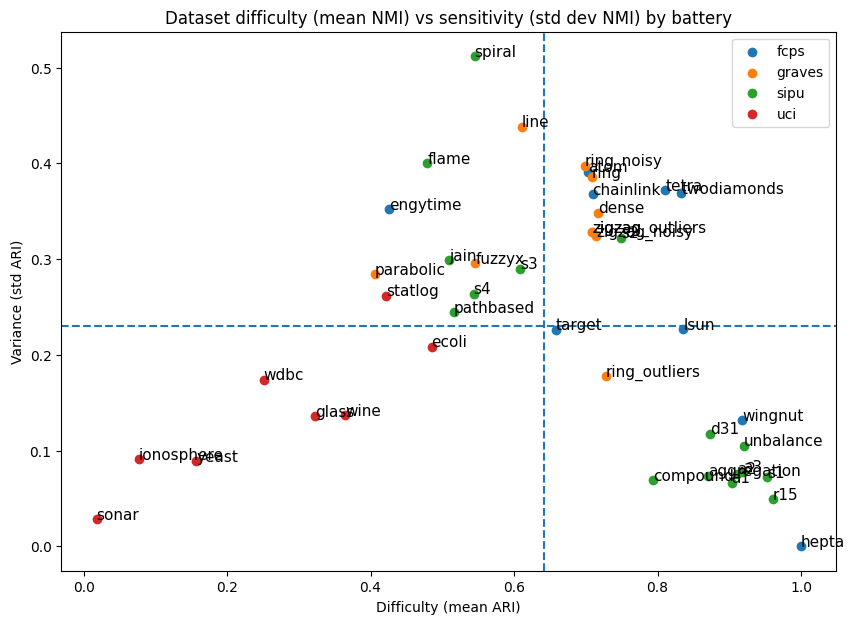

In [22]:
difficulty = df_all.groupby("Dataset")["NMI"].mean().rename("difficulty")
variance = df_all.groupby("Dataset")["NMI"].std().rename("variance")
dataset_info = pd.concat([difficulty, variance], axis=1)
x = dataset_info["difficulty"]
y = dataset_info["variance"]

plt.figure(figsize = (10,7))
for battery, group in df_all.groupby("Battery"):
    subset = dataset_info.loc[group["Dataset"].unique()]
    plt.scatter(subset["difficulty"], subset["variance"], label=battery)
for i, txt in enumerate(dataset_info.index):
    plt.annotate(txt, (x.iloc[i], y.iloc[i]), fontsize=11)
plt.axvline(x.mean(), linestyle='--')
plt.axhline(y.mean(), linestyle='--')
plt.legend()
plt.xlabel("Difficulty (mean ARI)")
plt.ylabel("Variance (std ARI)")
plt.title("Dataset difficulty (mean NMI) vs sensitivity (std dev NMI) by battery")
plt.show()

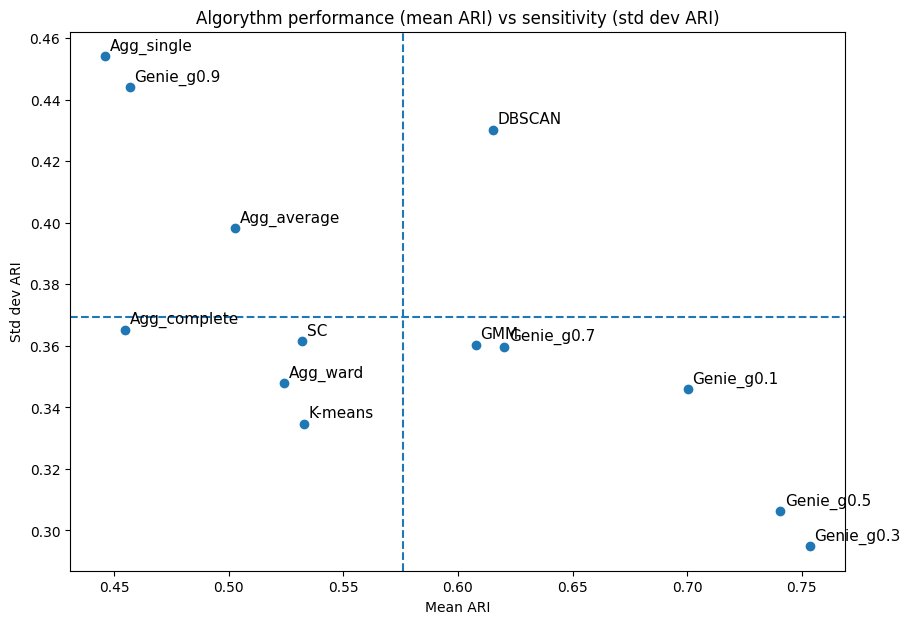

In [93]:
difficulty = df_all.groupby("Algorithm")["ARI"].mean().rename("difficulty")
variance = df_all.groupby("Algorithm")["ARI"].std().rename("variance")
alg_info = pd.concat([difficulty, variance], axis=1)
x = alg_info["difficulty"]
y = alg_info["variance"]

plt.figure(figsize = (10,7))
plt.scatter(x, y)
for i, txt in enumerate(alg_info.index):
    plt.annotate(txt, (x.iloc[i]+0.002, y.iloc[i]+0.002), fontsize=11)
plt.axvline(x.mean(), linestyle='--')
plt.axhline(y.mean(), linestyle='--')
plt.xlabel("Mean ARI")
plt.ylabel("Std dev ARI")
plt.title("Algorythm performance (mean ARI) vs sensitivity (std dev ARI)")
plt.show()

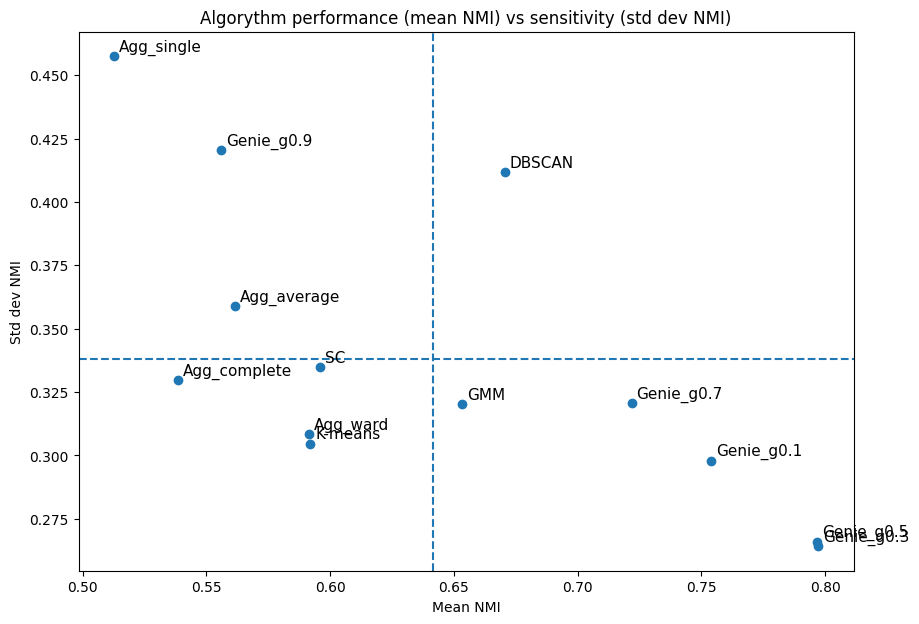

In [94]:
difficulty = df_all.groupby("Algorithm")["NMI"].mean().rename("difficulty")
variance = df_all.groupby("Algorithm")["NMI"].std().rename("variance")
alg_info = pd.concat([difficulty, variance], axis=1)
x = alg_info["difficulty"]
y = alg_info["variance"]

plt.figure(figsize = (10,7))
plt.scatter(x, y)
for i, txt in enumerate(alg_info.index):
    plt.annotate(txt, (x.iloc[i]+0.002, y.iloc[i]+0.002), fontsize=11)
plt.axvline(x.mean(), linestyle='--')
plt.axhline(y.mean(), linestyle='--')
plt.xlabel("Mean NMI")
plt.ylabel("Std dev NMI")
plt.title("Algorythm performance (mean NMI) vs sensitivity (std dev NMI)")
plt.show()

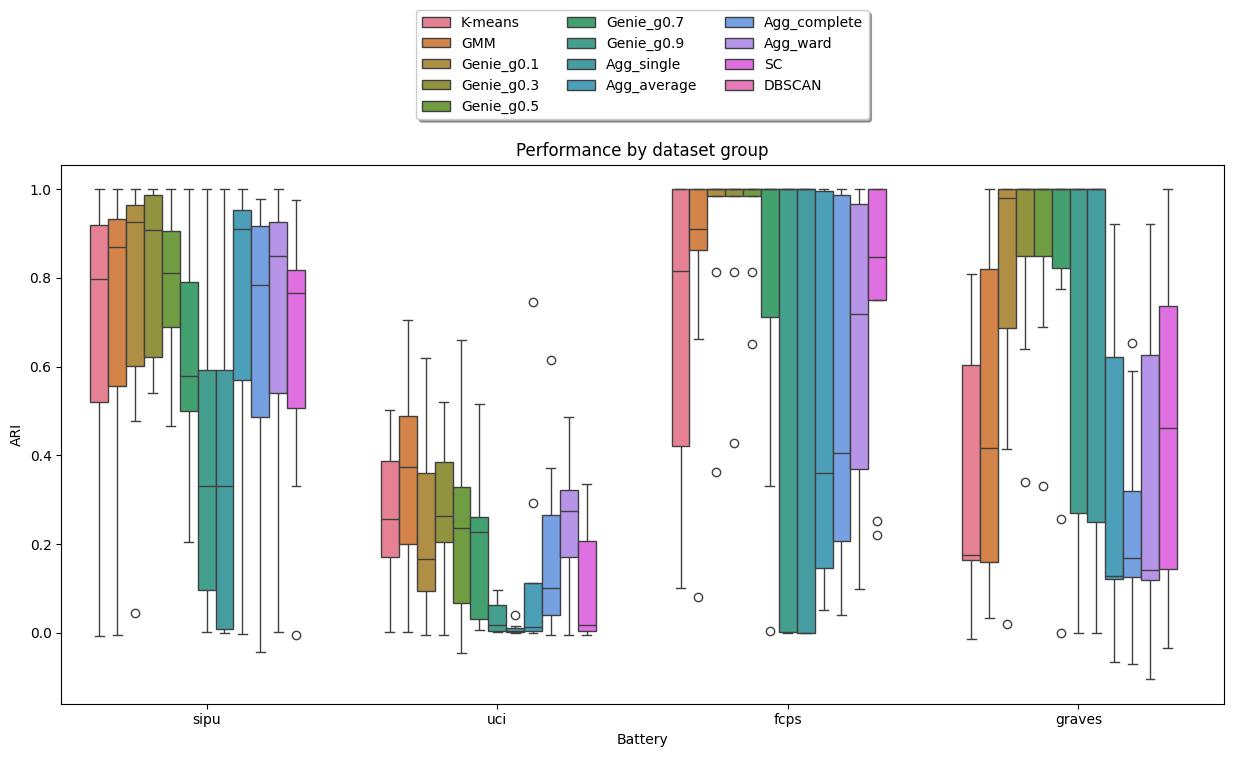

In [58]:
plt.figure(figsize = (15,7))
sns.boxplot(data=df_all, x="Battery", y="ARI", hue="Algorithm")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3),
          ncol=3, fancybox=True, shadow=True)
plt.title("Performance by dataset group")
plt.show()

In [61]:
df_dbscan[df_dbscan["Coverage"] != 1]

,Unnamed: 0,Dataset,MinPts,Epsilon,K_dbscan,K_reference,Coverage,median_reference,median_internal,ARI,NMI,NCA,Silhouette,Silhouette_W,Calinski_Harabasz,G_Dunn,Neg_Davies_Bouldin,Neg_WCSS
21,21,uci/wdbc,3,0.261637,8,2,0.972816,0.348002,0.463922,0.390972,0.305032,NaN,0.509952,0.515858,183.120978,0.417892,-0.588038,-533.130447
23,23,uci/yeast,6,1.813098,3,10,0.997962,0.025439,0.465976,0.009436,0.041442,NaN,0.431236,0.500716,69.327964,2.842694,-0.792851,-2655.644946


### DBSCAN

In [6]:
df_dbscan.drop("Unnamed: 0", axis=1)

,Dataset,MinPts,Epsilon,K_dbscan,K_reference,Coverage,median_reference,median_internal,ARI,NMI,NCA,Silhouette,Silhouette_W,Calinski_Harabasz,G_Dunn,Neg_Davies_Bouldin,Neg_WCSS
0,sipu/a1,6,0.085891,9,20,1.000000,0.642410,0.325998,0.471713,0.813107,NaN,0.398309,0.501612,4208.626703,0.253688,-0.796833,-362.241080
1,sipu/a2,3,0.064150,21,35,1.000000,0.643246,0.215711,0.451490,0.835002,NaN,0.218743,0.509766,3531.091521,0.212678,-0.911705,-616.443493
2,sipu/a3,3,0.058661,28,50,1.000000,0.669632,0.252811,0.480266,0.858998,NaN,0.292950,0.510319,5678.129822,0.212672,-0.713760,-672.616442
3,sipu/aggregation,7,0.180103,5,7,1.000000,0.849174,0.484372,0.808943,0.889406,NaN,0.412005,0.556739,754.200176,0.589219,-0.624948,-298.049751
4,sipu/compound,3,0.150955,5,6,1.000000,1.000000,0.412180,1.000000,1.000000,NaN,0.276735,0.547625,697.433121,0.600113,-3.424757,-45.002343
5,sipu/d31,5,0.095531,13,31,1.000000,0.552265,0.252064,0.323571,0.780958,NaN,0.382428,0.558135,2321.384327,0.121701,-0.600253,-592.901954
6,sipu/flame,3,0.127169,1,2,1.000000,0.000000,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sipu/jain,5,0.195892,5,2,1.000000,0.884928,0.307870,0.943329,0.826528,NaN,0.261166,0.479716,73.215133,0.354575,-0.810288,-232.490119
8,sipu/pathbased,3,0.220767,8,3,1.000000,0.607019,0.364981,0.563137,0.650901,NaN,0.275986,0.453976,199.194226,0.506189,-1.097814,-98.970055
9,sipu/r15,6,0.116264,15,15,1.000000,0.996587,0.771918,0.996177,0.996997,NaN,0.772008,0.771827,5442.955501,1.186205,-0.297438,-8.270401


In [4]:
df_dbscan[df_dbscan["K_dbscan"] == df_dbscan["K_reference"]]

,Unnamed: 0,Dataset,MinPts,Epsilon,K_dbscan,K_reference,Coverage,median_reference,median_internal,ARI,NMI,NCA,Silhouette,Silhouette_W,Calinski_Harabasz,G_Dunn,Neg_Davies_Bouldin,Neg_WCSS
9,9,sipu/r15,6,0.116264,15,15,1.0,0.996587,0.771918,0.996177,0.996997,NaN,0.772008,0.771827,5442.955501,1.186205,-0.297438,-8.270401
14,14,sipu/spiral,4,0.269885,3,3,1.0,1.000000,0.000941,1.000000,1.000000,NaN,0.000950,0.000932,5.926668,0.589996,-5.950132,-573.681147
15,15,sipu/unbalance,6,0.050602,8,8,1.0,1.000000,0.845389,1.000000,1.000000,NaN,0.863447,0.827330,239921.865987,2.703671,-0.239451,-16.099048
24,24,fcps/atom,5,0.713647,2,2,1.0,1.000000,0.311850,1.000000,1.000000,NaN,0.312197,0.311503,1.159507,1.152594,-20.200690,-2386.331259
25,25,fcps/chainlink,4,0.171823,2,2,1.0,1.000000,0.166652,1.000000,1.000000,NaN,0.166652,0.166652,250.864851,1.272731,-1.990319,-2173.672797
27,27,fcps/hepta,3,0.377380,7,7,1.0,1.000000,0.703921,1.000000,1.000000,NaN,0.705704,0.702138,516.796093,3.857030,-0.351740,-37.179833
28,28,fcps/lsun,6,0.360618,3,3,1.0,1.000000,0.486094,1.000000,1.000000,NaN,0.477456,0.494732,384.438682,0.809087,-0.708998,-271.334227
29,29,fcps/target,5,0.245607,2,2,1.0,1.000000,0.274320,1.000000,1.000000,NaN,0.284402,0.264238,0.493894,0.890862,-32.832506,-1301.531545
30,30,fcps/tetra,4,0.463134,4,4,1.0,1.000000,0.518438,1.000000,1.000000,NaN,0.518438,0.518438,416.356086,0.887604,-0.643752,-253.403784
31,31,fcps/twodiamonds,8,0.116709,2,2,1.0,1.000000,0.432245,1.000000,1.000000,NaN,0.630597,0.630597,2386.425758,0.233894,-0.541801,-163.791651


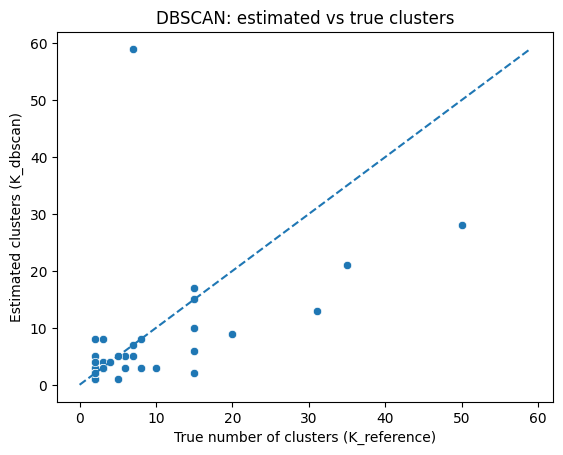

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.scatterplot(data=df_dbscan, x="K_reference", y="K_dbscan")

# linia idealna y=x
max_k = max(df_dbscan["K_reference"].max(), df_dbscan["K_dbscan"].max())
plt.plot([0, max_k], [0, max_k], linestyle='--')

plt.xlabel("True number of clusters (K_reference)")
plt.ylabel("Estimated clusters (K_dbscan)")
plt.title("DBSCAN: estimated vs true clusters")
plt.show()

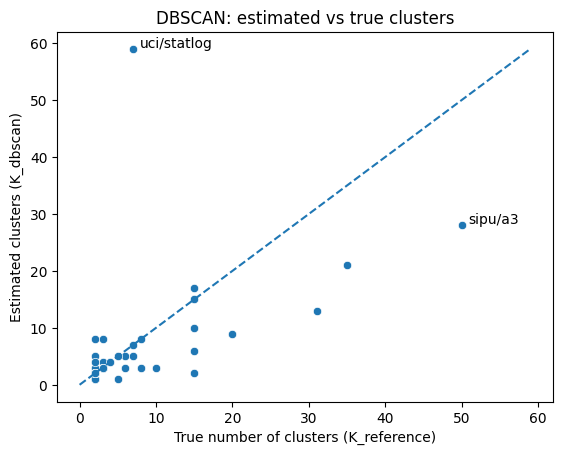

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_dbscan.copy()

df["error"] = (df["K_dbscan"] - df["K_reference"]).abs()

extreme_points = df.nlargest(2, "error")

plt.figure()

sns.scatterplot(data=df, x="K_reference", y="K_dbscan")

# linia idealna
max_k = max(df["K_reference"].max(), df["K_dbscan"].max())
plt.plot([0, max_k], [0, max_k], linestyle='--')

# anotacje
for _, row in extreme_points.iterrows():
    plt.annotate(
        row["Dataset"],  # zakładam, że masz kolumnę 'dataset'
        (row["K_reference"], row["K_dbscan"]),
        textcoords="offset points",
        xytext=(5, 1),
        fontsize=10
    )

plt.xlabel("True number of clusters (K_reference)")
plt.ylabel("Estimated clusters (K_dbscan)")
plt.title("DBSCAN: estimated vs true clusters")

plt.show()

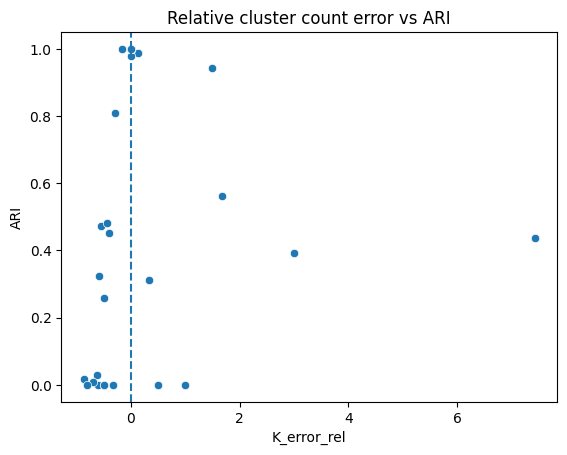

In [13]:
df_dbscan["K_error"] = df_dbscan["K_dbscan"] - df_dbscan["K_reference"]
df_dbscan["K_error_rel"] = df_dbscan["K_error"] / df_dbscan["K_reference"]

sns.scatterplot(data=df_dbscan, x="K_error_rel", y="ARI")
plt.axvline(0, linestyle='--')
plt.title("Relative cluster count error vs ARI")
plt.show()

In [28]:
def classify(row):
    if row["K_dbscan"] < row["K_reference"]:
        return "under"
    elif row["K_dbscan"] > row["K_reference"]:
        return "over"
    else:
        return "correct"

df_dbscan["K_case"] = df_dbscan.apply(classify, axis=1)
df_dbscan.groupby("K_case")["ARI"].count()

K_case
correct    19
over        8
under      16
Name: ARI, dtype: int64

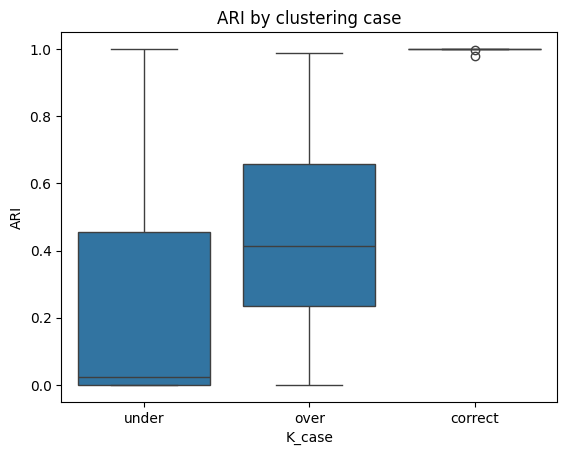

In [17]:
sns.boxplot(data=df_dbscan, x="K_case", y="ARI")
plt.title("ARI by clustering case")
plt.show()

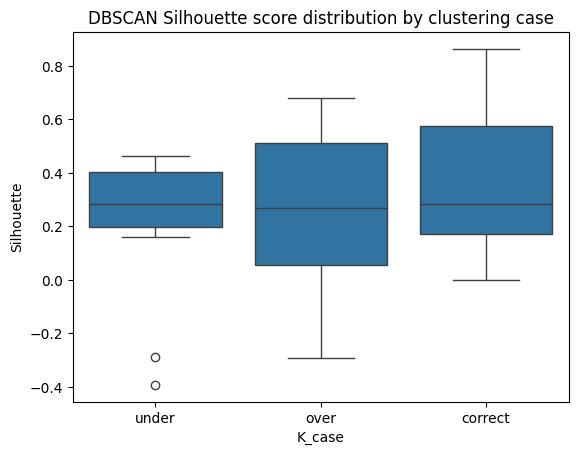

In [37]:
sns.boxplot(data=df_dbscan, x="K_case", y="Silhouette")
plt.title("DBSCAN Silhouette score distribution by clustering case")
plt.show()

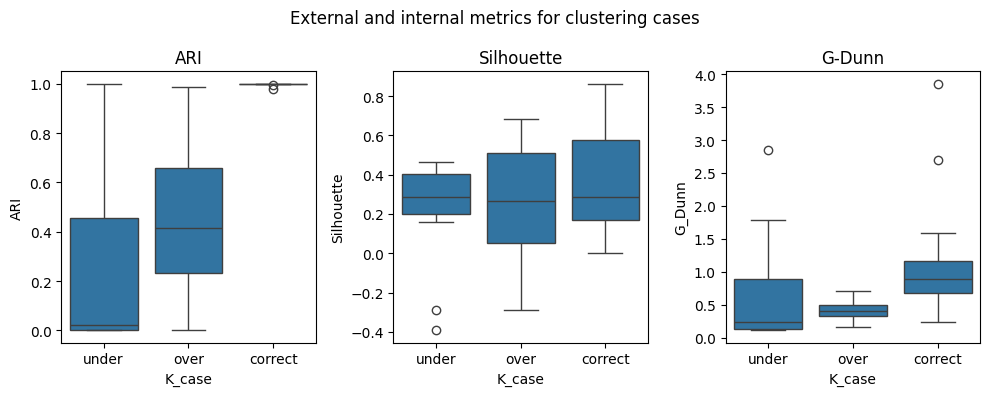

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

sns.boxplot(data=df_dbscan, x="K_case", y="ARI", ax=axes[0])
axes[0].set_title("ARI")

sns.boxplot(data=df_dbscan, x="K_case", y="Silhouette", ax=axes[1])
axes[1].set_title("Silhouette")

sns.boxplot(data=df_dbscan, x="K_case", y="G_Dunn", ax=axes[2])
axes[2].set_title("G-Dunn")

plt.suptitle("External and internal metrics for clustering cases")
plt.tight_layout()
plt.show()

In [18]:
print(df_dbscan[["K_dbscan", "K_reference", "ARI"]].corr())

             K_dbscan  K_reference       ARI
K_dbscan     1.000000     0.491582 -0.057457
K_reference  0.491582     1.000000 -0.216636
ARI         -0.057457    -0.216636  1.000000


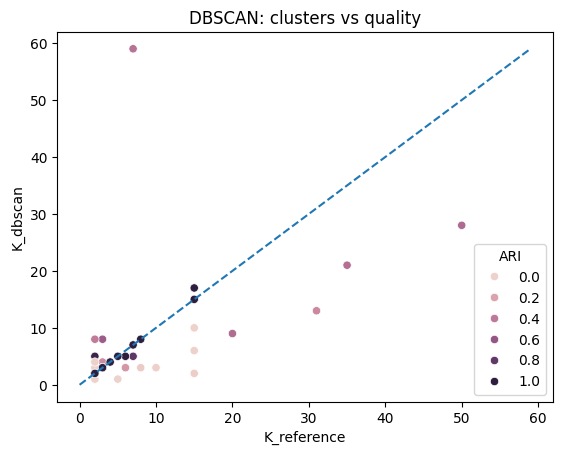

In [26]:
plt.figure()

sns.scatterplot(
    data=df_dbscan,
    x="K_reference",
    y="K_dbscan",
    hue="ARI"
)

plt.plot([0, max_k], [0, max_k], linestyle='--')

plt.title("DBSCAN: clusters vs quality")
plt.show()

Datasets for which dbscan estimated the right number of clusters

In [71]:
correct_cases = df_dbscan[df_dbscan["K_error"] == 0]["Dataset"].str.split("/").str[-1]

df_filtered = df_all[df_all["Dataset"].isin(correct_cases)]

final_comp = df_filtered[df_filtered["Algorithm"].isin(["Genie_g0.3", "DBSCAN"])]

print(final_comp)

             Dataset   Algorithm       ARI       NMI       NCA  Silhouette  \
111              r15  Genie_g0.3  0.985650  0.989310  0.992857    0.750624   
171           spiral  Genie_g0.3  1.000000  1.000000  1.000000    0.001344   
183        unbalance  Genie_g0.3  0.623751  0.767466  0.290714    0.296416   
291             atom  Genie_g0.3  1.000000  1.000000  1.000000    0.311493   
303        chainlink  Genie_g0.3  1.000000  1.000000  1.000000    0.166652   
327            hepta  Genie_g0.3  1.000000  1.000000  1.000000    0.701923   
339             lsun  Genie_g0.3  1.000000  1.000000  1.000000    0.477456   
351           target  Genie_g0.3  0.429111  0.584170  0.734177    0.285239   
363            tetra  Genie_g0.3  1.000000  1.000000  1.000000    0.505789   
375      twodiamonds  Genie_g0.3  0.985038  0.968118  0.992500    0.629732   
387          wingnut  Genie_g0.3  1.000000  1.000000  1.000000    0.448230   
399            dense  Genie_g0.3  0.960200  0.929125  0.980000  